# SLM phase-calibration workflow

This notebook uses the existing live camera viewer to identify diffraction-order positions while keeping acquisition, persistence, and plotting in reusable Python functions.

Workflow:

1. Configure and connect to the camera and SLM.
2. Display a binary grating and locate the 0th, +1st, and -1st diffraction orders.
3. Enter and confirm the camera coordinates.
4. Acquire the grey-level sweep and immediately save the raw measurements with metadata.
5. Adjust the fit parameters until the measured and fitted curves agree.
6. Explicitly approve LUT generation, installation, and validation.

The acquisition and LUT installation switches default to `False` to prevent accidental hardware operations.

## 1. Start the hardware servers

Start the camera and SLM servers before connecting. On the Linux control machine the existing server session can be opened with:

```bash
tmux attach -t pwi_servers
```

In [1]:
%matplotlib inline

from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import JazLabs.hardware.Cameras.Camera_Client as CameraClientLib
import JazLabs.hardware.SLM.PhaseMaskClass as PhaseMaskClass
from JazLabs.hardware.SLM.SLMStack import SLMClient
import JazLabs.procedures.SLM.SLM_PhaseCalibration as PhaseCalibration
import JazLabs.procedures.SLM.SLMPhaseCalibrationFunctions as PhaseAnalysis

%load_ext autoreload
%aimport JazLabs.procedures.SLM.SLM_PhaseCalibration
%aimport JazLabs.procedures.SLM.SLMPhaseCalibrationFunctions
%autoreload 1

plt.style.use("dark_background")

## 2. Configuration

Edit this cell before connecting. Use the live camera viewer and the two SLM display cells below to determine the three diffraction-order centres. Set `ACQUIRE_NEW_DATA = True` only after confirming those coordinates. After acquisition, return it to `False` so fit cells can be rerun without repeating the hardware scan.

In [ ]:
# Hardware connections.
SERVER_HOST = "127.0.0.1"
CAMERA_COMMAND_PORT = 50733
CAMERA_FRAME_PORT = 50734
SLM_COMMAND_PORT = 5555
SLM_DISPLAY_PORT = 5556

# SLM and mask settings.
CHANNEL = "Red"
POLARISATION = "H"
MASK_INDEX = 0
MASK_PROPERTIES_FILENAME = "SLM_CenterAlignment.npy"
SLM_PIXEL_SIZE = 17e-6
SLM_WAVELENGTH = 1550e-9

# Binary diffraction grating and acquisition.
GRATING_DIRECTION = "y"
STRIPE_WIDTH = 25
DIAGNOSTIC_GREY_LEVEL = 128
BACKGROUND_LEVEL = 0
CAMERA_FRAME_AVERAGES = 1
APERTURE_HALF_WIDTH_X = 10
APERTURE_HALF_WIDTH_Y = 10

# Read these positions from the live camera viewer.
# The aperture code expects [row, column], equivalent to viewer [y, x].
ZEROTH_ORDER_CENTER_ROW_COLUMN = [66, 63]
PLUS_FIRST_ORDER_CENTER_ROW_COLUMN = [66, 99]
MINUS_FIRST_ORDER_CENTER_ROW_COLUMN = [66, 26]

# Raw calibration data.
RAW_DATA_FILE = Path(
    "../calibrations/SLM/CustomLutFiles/PowerPhaseCalibration.npz"
)
ACQUIRE_NEW_DATA = False

# Fit parameters. Change these and rerun only the fit cell.
FIT_N_KNOTS = 18
FIT_POLYNOMIAL_DEGREE = 10
FIT_PHASE_MAX_GUESS = 3 * np.pi
FIT_CURVATURE_PENALTY = 0.2
FIT_ROBUST = False

# LUT generation is deliberately gated by two switches.
FIT_ACCEPTED = True
GENERATE_LUT = True
BASE_LUT_FILE = Path(
    "../calibrations/SLM/CustomLutFiles/NewLutFile_3.lut"
)
NEW_LUT_PREFIX = Path(
    "../calibrations/SLM/CustomLutFiles/SLM_PhaseCalibration_New"
)
PHASE_STROKE = 2 * np.pi
PHASE_OFFSET = 0.0

# Copy the generated LUT to Windows separately before enabling this.
LOAD_GENERATED_LUT = False
WINDOWS_INSTALLED_LUT_FILE = (
    r"C:\SLM_LUTFiles\SLM_PhaseCalibration_New.lut"
)
RUN_VALIDATION_SCAN = False

## 3. Connect to the camera and SLM

Existing clients are closed first so this cell can be rerun safely. The current mask centres are then loaded from the centre-alignment calibration.

In [3]:
try:
    camera_client.close()
except NameError:
    pass

camera_client = CameraClientLib.CameraClient(
    host=SERVER_HOST,
    command_port=CAMERA_COMMAND_PORT,
    frame_pub_port=CAMERA_FRAME_PORT,
    timeout_ms=60000,
    client_id="slm_phase_calibration_notebook",
)
camera_properties = camera_client.GetProperties()

In [4]:
try:
    slm_client.close()
except NameError:
    pass

slm_client = SLMClient(
    host=SERVER_HOST,
    command_port=SLM_COMMAND_PORT,
    display_pub_port=SLM_DISPLAY_PORT,
    timeout_ms=5000,
    attach_viewer_shared_memory=False,
)
phase_mask = PhaseMaskClass.PhaseMaskObject(
    SLMObject=slm_client,
    ActiveRGBChannels=[CHANNEL],
    pixel_size=SLM_PIXEL_SIZE,
    wavelength=SLM_WAVELENGTH,
)
phase_mask.polProps[CHANNEL]["V"].polEnabled = False
phase_mask.LoadMaskProperties(
    filenamePrefix=MASK_PROPERTIES_FILENAME,
    PolSelector=POLARISATION,
)


        Zern Coefs:
        0:  piston    ( 0,  0 )
        1:  Tiltx     (1,  -1 )
        2:  Tilty     ( 1,  1 )
        3:  Astigx    (2,  -2 )
        4:  Defocus   ( 2,  0 )
        5:  Astigy    ( 2,  2 )
        6:  Trefilx   (3,  -3 )
        7:  Comax     (3,  -1 )
        8:  Comay     ( 1,  3 )
        9:  Trefoily  ( 3,  3 )
        12:  Spherical ( 4,  0 )
        
1024
1024
[  1   1 256 256]


## 4. Locate the diffraction orders in the live camera viewer

Use the next two cells while watching the separate live camera viewer:

1. Run the blank-SLM cell and record the zeroth-order position.
2. Run the binary-grating cell and record the +1 and -1 order positions.
3. Enter the three positions in the configuration cell above and rerun it.

The viewer normally reports `(x, y)`. Enter each centre above as `[row, column]`, which is `[y, x]`.

In [5]:
phase_mask.Clear_Display(CHANNEL)
print("The SLM is blank. Read the zeroth-order (x, y) position from the live camera viewer.")

The SLM is blank. Read the zeroth-order (x, y) position from the live camera viewer.


In [6]:
PhaseCalibration.DisplayBinaryDiffractionPattern(
    phase_mask,
    CHANNEL,
    Direction=GRATING_DIRECTION,
    strip_width=STRIPE_WIDTH,
    strip_value=DIAGNOSTIC_GREY_LEVEL,
)
print("The binary grating is displayed. Read the +1 and -1 (x, y) positions from the live camera viewer.")

The binary grating is displayed. Read the +1 and -1 (x, y) positions from the live camera viewer.


## 5. Confirm the camera coordinates

After entering the viewer positions in the configuration cell, run this cell to confirm the `[row, column]` values that will be used by the calibration scan.

In [7]:
diffraction_order_centers = {
    "0th": list(ZEROTH_ORDER_CENTER_ROW_COLUMN),
    "+1st": list(PLUS_FIRST_ORDER_CENTER_ROW_COLUMN),
    "-1st": list(MINUS_FIRST_ORDER_CENTER_ROW_COLUMN),
}

print("Camera centres used by the scan [row, column]:")
for order_label, center_row_column in diffraction_order_centers.items():
    print(f"  {order_label}: {center_row_column}")

Camera centres used by the scan [row, column]:
  0th: [66, 63]
  +1st: [66, 99]
  -1st: [66, 26]


## 6. Acquire or load the raw calibration

Set `ACQUIRE_NEW_DATA = True` only after confirming the three camera coordinates. The acquisition scans grey levels from 0 to 255 in order, averages the requested number of frames, records a cleared-SLM reference in the final array entry, and restores the camera and SLM afterward. Raw measurements are saved immediately with their acquisition metadata.

In [10]:
ACQUIRE_NEW_DATA= True

In [11]:
if ACQUIRE_NEW_DATA:
    zero_order_power, plus_first_power, minus_first_power = (
        PhaseCalibration.PhaseCalibration_BinaryDiffraction_Cam_0thAnd1stOrder(
            slm=phase_mask,
            Cam=camera_client,
            channel=CHANNEL,
            Direction=GRATING_DIRECTION,
            imask=MASK_INDEX,
            pol=POLARISATION,
            backgroundLevel=BACKGROUND_LEVEL,
            strip_width=STRIPE_WIDTH,
            camframeAvg=CAMERA_FRAME_AVERAGES,
            ixCamCenter0th=diffraction_order_centers["0th"][0],
            iyCamCenter0th=diffraction_order_centers["0th"][1],
            ixCamCenter_plus1st=diffraction_order_centers["+1st"][0],
            iyCamCenter_plus1st=diffraction_order_centers["+1st"][1],
            ixCamCenter_minus1st=diffraction_order_centers["-1st"][0],
            iyCamCenter_minus1st=diffraction_order_centers["-1st"][1],
            x_half_width=APERTURE_HALF_WIDTH_X,
            y_half_width=APERTURE_HALF_WIDTH_Y,
            phaseLevels=256,
            Verbose=True,
        )
    )

    acquisition_metadata = {
        "acquired_at": datetime.now().astimezone().isoformat(),
        "channel": CHANNEL,
        "polarisation": POLARISATION,
        "mask_index": MASK_INDEX,
        "slm_wavelength_m": SLM_WAVELENGTH,
        "slm_pixel_size_m": SLM_PIXEL_SIZE,
        "grating_direction": GRATING_DIRECTION,
        "stripe_width_px": STRIPE_WIDTH,
        "camera_frame_averages": CAMERA_FRAME_AVERAGES,
        "aperture_half_width_x_px": APERTURE_HALF_WIDTH_X,
        "aperture_half_width_y_px": APERTURE_HALF_WIDTH_Y,
        "diffraction_order_centers": diffraction_order_centers,
    }
    saved_path = PhaseCalibration.SavePhaseCalibrationMeasurements(
        RAW_DATA_FILE,
        zero_order_power,
        plus_first_power,
        minus_first_power,
        metadata=acquisition_metadata,
    )
    print(f"Saved raw calibration to {saved_path}")
else:
    measurements, acquisition_metadata = (
        PhaseCalibration.LoadPhaseCalibrationMeasurements(RAW_DATA_FILE)
    )
    zero_order_power = measurements["PowerValues_0th"]
    plus_first_power = measurements["PowerValues_plus1st"]
    minus_first_power = measurements["PowerValues_minus1st"]
    print(f"Loaded raw calibration from {RAW_DATA_FILE}")

acquisition_metadata

Acquiring grey level 0/255
Acquiring grey level 16/255
Acquiring grey level 32/255
Acquiring grey level 48/255
Acquiring grey level 64/255
Acquiring grey level 80/255
Acquiring grey level 96/255
Acquiring grey level 112/255
Acquiring grey level 128/255
Acquiring grey level 144/255
Acquiring grey level 160/255
Acquiring grey level 176/255
Acquiring grey level 192/255
Acquiring grey level 208/255
Acquiring grey level 224/255
Acquiring grey level 240/255
Acquiring grey level 255/255
Saved raw calibration to ..\calibrations\SLM\CustomLutFiles\PowerPhaseCalibration.npz


{'acquired_at': '2026-07-20T12:40:10.844871+10:00',
 'channel': 'Red',
 'polarisation': 'H',
 'mask_index': 0,
 'slm_wavelength_m': 1.55e-06,
 'slm_pixel_size_m': 1.7e-05,
 'grating_direction': 'y',
 'stripe_width_px': 25,
 'camera_frame_averages': 1,
 'aperture_half_width_x_px': 10,
 'aperture_half_width_y_px': 10,
 'diffraction_order_centers': {'0th': [66, 63],
  '+1st': [66, 99],
  '-1st': [66, 26]}}

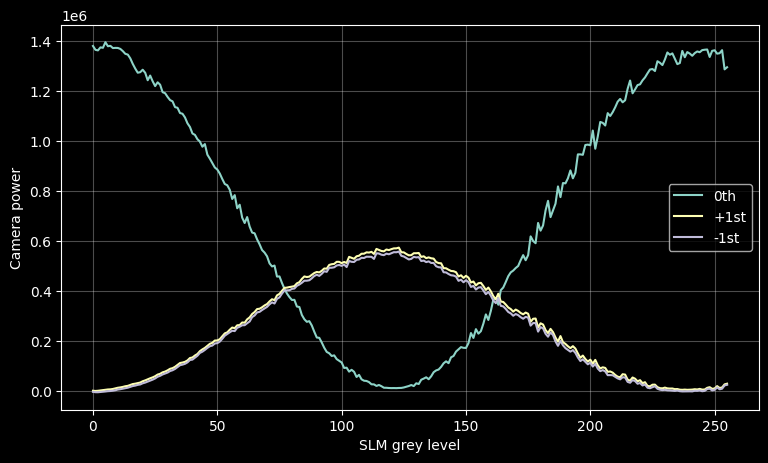

(<Figure size 900x500 with 1 Axes>,
 <Axes: xlabel='SLM grey level', ylabel='Camera power'>)

In [12]:
PhaseCalibration.PlotPhaseCalibrationMeasurements(
    zero_order_power,
    plus_first_power,
    minus_first_power,
    include_reference=False,
)

## 7. Fit and inspect the phase response

This is the main iterative stage. Adjust only the fit settings in the configuration cell, then rerun this cell. Check that both power curves are represented and that the recovered phase is smooth, monotonic, and physically plausible. Do not generate a LUT until the fit is accepted.

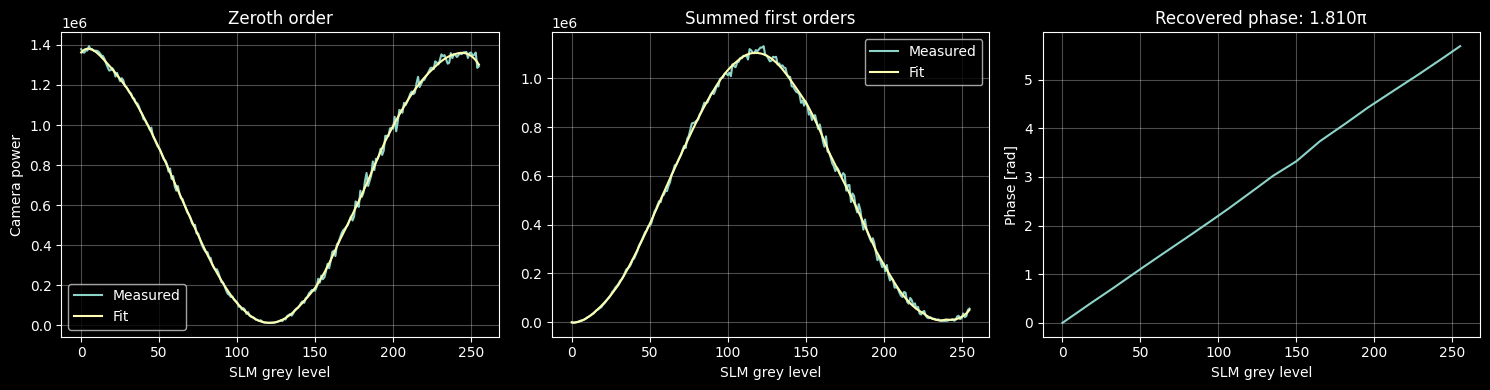

Recovered phase stroke: 1.8101π
Fit success: True
Fit message: `ftol` termination condition is satisfied.


In [13]:
grey_levels = np.arange(zero_order_power.size - 1)
phase_fit = PhaseAnalysis.fit_slm_phase_I0_Ipm1(
    grey_levels,
    zero_order_power[:-1],
    plus_first_power[:-1],
    minus_first_power[:-1],
    n_knots=FIT_N_KNOTS,
    poly_deg=FIT_POLYNOMIAL_DEGREE,
    phi_max_guess=FIT_PHASE_MAX_GUESS,
    lam_curv=FIT_CURVATURE_PENALTY,
    robust=FIT_ROBUST,
)
PhaseCalibration.PlotPhaseCalibrationFit(
    phase_fit,
    zero_order_power,
    plus_first_power,
    minus_first_power,
)
print(f"Recovered phase stroke: {phase_fit['phi_end'] / np.pi:.4f}π")
print(f"Fit success: {phase_fit['scipy_result'].success}")
print(f"Fit message: {phase_fit['scipy_result'].message}")

## 8. Generate the LUT after accepting the fit

Review the plots first. Then set both `FIT_ACCEPTED = True` and `GENERATE_LUT = True` in the configuration cell. The existing LUT is used as the voltage basis and the new `.lut` and `.blt` files are written using `NEW_LUT_PREFIX`.

In [ ]:
if not FIT_ACCEPTED:
    print("LUT not generated: set FIT_ACCEPTED = True after reviewing the fit.")
elif not GENERATE_LUT:
    print("LUT not generated: set GENERATE_LUT = True when ready.")
else:
    NEW_LUT_PREFIX.parent.mkdir(parents=True, exist_ok=True)
    recovered_phase = phase_fit["phi"]
    phase_count = recovered_phase.size
    overlap_signal_reference = np.exp(1j * recovered_phase)
    overlap_reference_reference = recovered_phase
    overlap_signal_signal = recovered_phase

    lut_results = PhaseAnalysis.CalculatePhaseAndVoltageLevels(
        True,
        str(BASE_LUT_FILE),
        str(NEW_LUT_PREFIX),
        phase_count,
        PHASE_STROKE,
        PHASE_OFFSET,
        overlap_signal_reference,
        overlap_reference_reference,
        overlap_signal_signal,
    )
    print(f"Generated {NEW_LUT_PREFIX}.lut and {NEW_LUT_PREFIX}.blt")

## 9. Install and load the accepted LUT

Copy the generated LUT to the Windows SLM machine separately, for example with `scp`. Verify the destination filename, update `WINDOWS_INSTALLED_LUT_FILE`, and only then set `LOAD_GENERATED_LUT = True`.

In [ ]:
if LOAD_GENERATED_LUT:
    slm_client.LoadLutFile(WINDOWS_INSTALLED_LUT_FILE)
    print(f"Loaded LUT: {WINDOWS_INSTALLED_LUT_FILE}")
else:
    print("Generated LUT was not loaded.")

## 10. Optional validation scan

After installing the new LUT, enable `RUN_VALIDATION_SCAN` to repeat the same measurement and inspect the recovered phase response. This does not overwrite the original raw calibration file.

In [ ]:
if RUN_VALIDATION_SCAN:
    validation_zero, validation_plus, validation_minus = (
        PhaseCalibration.PhaseCalibration_BinaryDiffraction_Cam_0thAnd1stOrder(
            slm=phase_mask,
            Cam=camera_client,
            channel=CHANNEL,
            Direction=GRATING_DIRECTION,
            imask=MASK_INDEX,
            pol=POLARISATION,
            backgroundLevel=BACKGROUND_LEVEL,
            strip_width=STRIPE_WIDTH,
            camframeAvg=CAMERA_FRAME_AVERAGES,
            ixCamCenter0th=diffraction_order_centers["0th"][0],
            iyCamCenter0th=diffraction_order_centers["0th"][1],
            ixCamCenter_plus1st=diffraction_order_centers["+1st"][0],
            iyCamCenter_plus1st=diffraction_order_centers["+1st"][1],
            ixCamCenter_minus1st=diffraction_order_centers["-1st"][0],
            iyCamCenter_minus1st=diffraction_order_centers["-1st"][1],
            x_half_width=APERTURE_HALF_WIDTH_X,
            y_half_width=APERTURE_HALF_WIDTH_Y,
            Verbose=True,
        )
    )
    validation_levels = np.arange(validation_zero.size - 1)
    validation_fit = PhaseAnalysis.fit_slm_phase_I0_Ipm1(
        validation_levels,
        validation_zero[:-1],
        validation_plus[:-1],
        validation_minus[:-1],
        n_knots=FIT_N_KNOTS,
        poly_deg=FIT_POLYNOMIAL_DEGREE,
        phi_max_guess=FIT_PHASE_MAX_GUESS,
        lam_curv=FIT_CURVATURE_PENALTY,
        robust=FIT_ROBUST,
    )
    PhaseCalibration.PlotPhaseCalibrationFit(
        validation_fit,
        validation_zero,
        validation_plus,
        validation_minus,
    )
else:
    print("Validation scan was not run.")

## 11. Disconnect

Clear the SLM and close both clients when calibration work is complete.

In [ ]:
phase_mask.Clear_Display(CHANNEL)
camera_client.close()
slm_client.close()